# MSI Pipeline - Script 05: Clustering

This notebook performs dimensionality reduction and clustering on MSI data.

## Workflow
1. Highly variable feature selection (top N channels)
2. PCA: 21-25 components
3. KNN graph: 15 neighbors
4. Leiden clustering: resolution 0.3-0.6
5. UMAP: 2D embedding for visualization

## Parameters (from successful workflows)
- n_pcs: 21
- n_neighbors: 15
- leiden_resolution: 0.6
- umap_min_dist: 0.1

## Input
- Preprocessed AnnData files (optionally with Moran's I from script04)

## Output
- AnnData with clustering results
- Cluster assignments (CSV)
- UMAP coordinates (CSV)

In [1]:
import sys
from pathlib import Path
import logging

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory for imports
sys.path.insert(0, str(Path.cwd().parent))

from utils import clustering as msi_cluster
from utils import io as msi_io

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Plot settings
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
sc.settings.verbosity = 2

c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
# === CONFIGURE THESE PATHS ===

# Base data directory
BASE_DIR = Path(r"T:/Sammy Data/Third set results/")  # Path.home() / "ext_hd_sammy"
#BASE_DIR = Path.home() / "ext_hd_sammy"

# Input: Preprocessed AnnData files
INPUT_DIR = BASE_DIR / "peptides_h5ad_processed"

# Output directories
OUTPUT_DIR = BASE_DIR / "peptides_clustering_results"

# Clustering parameters
N_PCS = 21  # Number of principal components
N_NEIGHBORS = 15  # KNN neighbors for graph construction
LEIDEN_RESOLUTION = 0.6  # Leiden clustering resolution
UMAP_MIN_DIST = 0.1  # UMAP minimum distance

# Feature selection
USE_SPATIALLY_COHERENT = True  # Use only spatially coherent channels (from script04)
N_TOP_FEATURES = 50  # Number of top features if not using spatial filtering

# Random seed for reproducibility
RANDOM_STATE = 42

# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input directory: {INPUT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"\nClustering parameters:")
print(f"  n_pcs: {N_PCS}")
print(f"  n_neighbors: {N_NEIGHBORS}")
print(f"  leiden_resolution: {LEIDEN_RESOLUTION}")

Input directory: T:\Sammy Data\Third set results\peptides_h5ad_processed
Output directory: T:\Sammy Data\Third set results\peptides_clustering_results

Clustering parameters:
  n_pcs: 21
  n_neighbors: 15
  leiden_resolution: 0.6


## Discover Samples

In [3]:
# Find all h5ad files
sample_files = list(INPUT_DIR.glob("*.h5ad"))
sample_ids = [f.stem for f in sample_files]

print(f"Found {len(sample_ids)} samples:")
for sid in sample_ids:
    print(f"  - {sid}")

Found 40 samples:
  - S001 ovary manual peptides
  - S004 ovary manual peptides
  - S005 ovary manual peptides
  - S006 ovary manual peptides
  - S019 ovary manual peptides
  - S020 ovary manual peptides
  - S022 ovary manual peptides
  - S023 ovary manual peptides
  - S024 ovary manual peptides
  - S025 ovary manual peptides
  - S026 ovary manual peptides
  - S030 ovary manual peptides
  - S032 ovary manual peptides
  - S033 ovary manual peptides
  - S034 ovary manual peptides
  - S044 ovary manual peptides
  - S045 ovary manual peptides
  - S046 ovary manual peptides
  - S047 ovary manual peptides
  - SO11 ovary manual peptides
  - SO14 ovary manual peptides
  - SO15 ovary manual peptides
  - SO36 ovary manual peptides
  - SO39 ovary manual peptides
  - SO40 ovary manual peptides
  - SO48 ovary manual peptides
  - SO50 ovary manual peptides
  - SO51 ovary manual peptides
  - SO52 ovary manual peptides
  - SO53 ovary manual peptides
  - SO54 ovary manual peptides
  - SO55 ovary manual

## Load Sample

In [4]:
# Load first sample
if sample_files:
    sample_file = sample_files[0]
    sample_id = sample_file.stem
    
    print(f"Loading {sample_id}...")
    adata = ad.read_h5ad(sample_file)
    
    print(f"Shape: {adata.shape}")
    print(f"\n.var columns: {list(adata.var.columns)}")
    
    # Check for spatial coherence info
    if 'spatially_coherent' in adata.var.columns:
        n_coherent = adata.var['spatially_coherent'].sum()
        print(f"Spatially coherent channels: {n_coherent}")

Loading S001 ovary manual peptides...
Shape: (264701, 773)

.var columns: ['channel_name', 'modality', 'mean', 'std', 'median', 'min', 'max', 'pct_nonzero', 'pct_5', 'pct_95', 'morans_i_I', 'morans_i_p', 'spatially_coherent']
Spatially coherent channels: 78


## Feature Selection

In [5]:
def select_features(adata, use_spatial=True, n_top=50):
    """Select features for clustering."""
    
    if use_spatial and 'spatially_coherent' in adata.var.columns:
        # Use spatially coherent channels
        mask = adata.var['spatially_coherent'].values
        n_selected = mask.sum()
        print(f"Using {n_selected} spatially coherent channels")
        
        if n_selected < 10:
            print(f"Warning: Only {n_selected} coherent channels, using top variance instead")
            use_spatial = False
        else:
            return adata[:, mask].copy()
    
    if not use_spatial:
        # Select by variance
        X = adata.X if not hasattr(adata.X, 'toarray') else adata.X.toarray()
        variances = np.var(X, axis=0)
        top_idx = np.argsort(variances)[-n_top:][::-1]
        
        print(f"Selected top {len(top_idx)} channels by variance")
        return adata[:, top_idx].copy()
    
    return adata.copy()

In [6]:
# Select features
adata_selected = select_features(
    adata, 
    use_spatial=USE_SPATIALLY_COHERENT, 
    n_top=N_TOP_FEATURES
)

print(f"\nSelected data shape: {adata_selected.shape}")

Using 78 spatially coherent channels

Selected data shape: (264701, 78)


## PCA

In [7]:
# Run PCA
print(f"Running PCA with {N_PCS} components...")

# Adjust n_pcs if fewer features than requested
n_pcs = min(N_PCS, adata_selected.n_vars - 1, adata_selected.n_obs - 1)

sc.tl.pca(adata_selected, n_comps=n_pcs, random_state=RANDOM_STATE)

print(f"PCA complete: {n_pcs} components")

Running PCA with 21 components...
computing PCA
    with n_comps=21
    finished (0:00:03)
PCA complete: 21 components


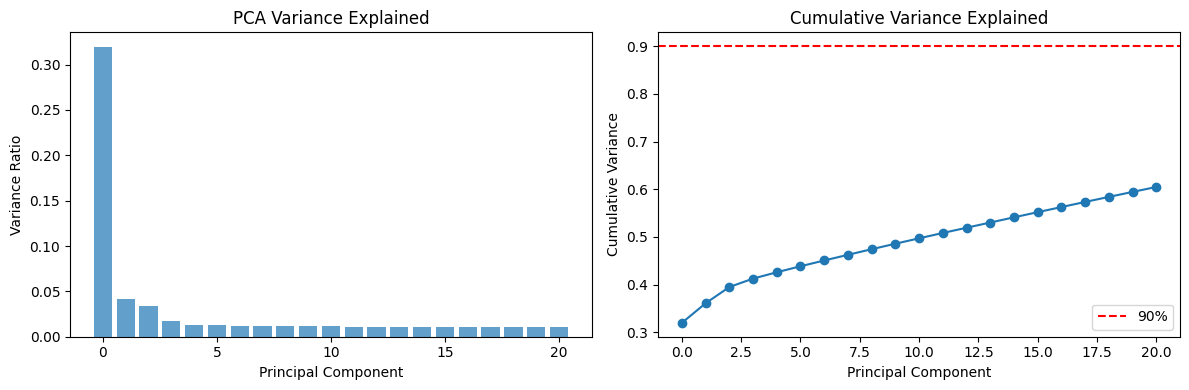

Variance explained by 21 PCs: 60.5%


In [8]:
# Visualize PCA variance explained
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Variance ratio
ax = axes[0]
variance_ratio = adata_selected.uns['pca']['variance_ratio']
ax.bar(range(len(variance_ratio)), variance_ratio, alpha=0.7)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Ratio')
ax.set_title('PCA Variance Explained')

# Cumulative variance
ax = axes[1]
cumulative = np.cumsum(variance_ratio)
ax.plot(range(len(cumulative)), cumulative, 'o-')
ax.axhline(0.9, color='r', linestyle='--', label='90%')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative Variance')
ax.set_title('Cumulative Variance Explained')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{sample_id}_pca_variance.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance explained by {n_pcs} PCs: {cumulative[-1]:.1%}")

## Neighbor Graph & Clustering

In [9]:
# Build neighbor graph
print(f"Building neighbor graph (k={N_NEIGHBORS})...")
sc.pp.neighbors(adata_selected, n_neighbors=N_NEIGHBORS, n_pcs=n_pcs, 
                random_state=RANDOM_STATE)

# Leiden clustering
print(f"Running Leiden clustering (resolution={LEIDEN_RESOLUTION})...")
sc.tl.leiden(adata_selected, resolution=LEIDEN_RESOLUTION, random_state=RANDOM_STATE)

# Count clusters
n_clusters = adata_selected.obs['leiden'].nunique()
print(f"Found {n_clusters} clusters")

Building neighbor graph (k=15)...
computing neighbors
    using 'X_pca' with n_pcs = 21
    finished (0:00:56)
Running Leiden clustering (resolution=0.6)...
running Leiden clustering


C:\Users\users_\AppData\Local\Temp\ipykernel_56708\2501567785.py:8: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_selected, resolution=LEIDEN_RESOLUTION, random_state=RANDOM_STATE)


    finished (0:09:17)
Found 7 clusters


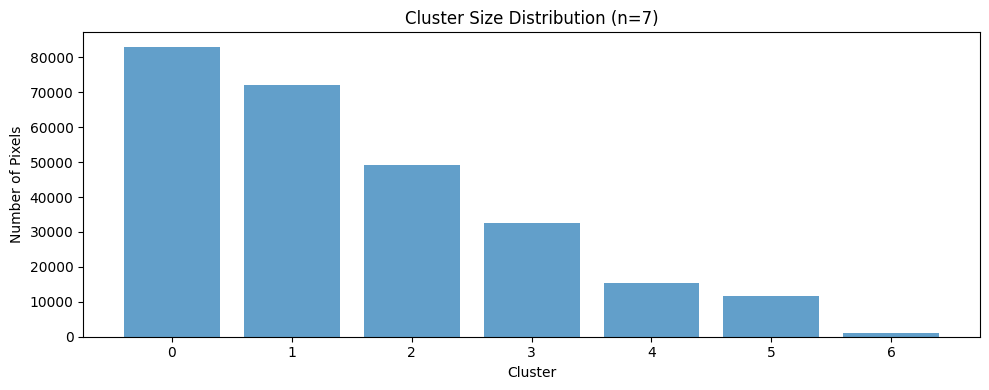


Cluster sizes:
leiden
0    83042
1    72008
2    49177
3    32502
4    15406
5    11620
6      946
Name: count, dtype: int64


In [10]:
# Cluster size distribution
cluster_sizes = adata_selected.obs['leiden'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cluster_sizes.index.astype(int), cluster_sizes.values, alpha=0.7)
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of Pixels')
ax.set_title(f'Cluster Size Distribution (n={n_clusters})')

plt.tight_layout()
plt.show()

print("\nCluster sizes:")
print(cluster_sizes)

## UMAP

In [11]:
# Run UMAP
print(f"Computing UMAP (min_dist={UMAP_MIN_DIST})...")
sc.tl.umap(adata_selected, min_dist=UMAP_MIN_DIST, random_state=RANDOM_STATE)

print("UMAP complete")

Computing UMAP (min_dist=0.1)...
computing UMAP
    finished (0:03:28)
UMAP complete


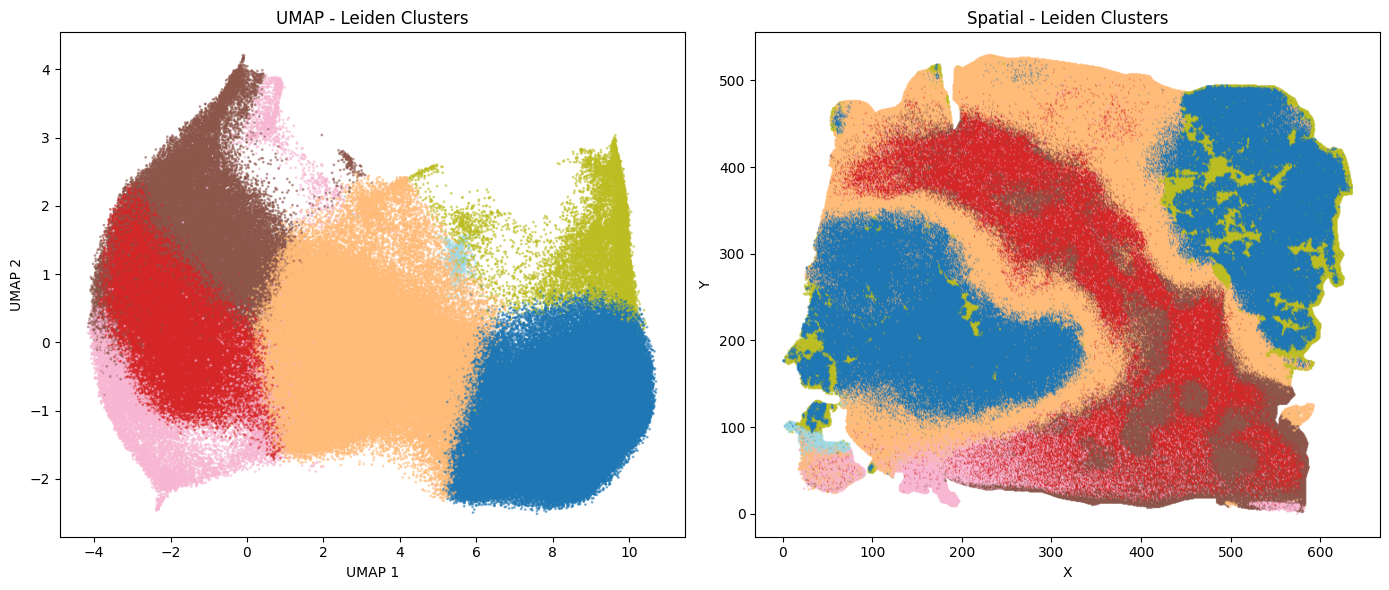

In [12]:
# Visualize UMAP colored by cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# UMAP with clusters
ax = axes[0]
scatter = ax.scatter(
    adata_selected.obsm['X_umap'][:, 0],
    adata_selected.obsm['X_umap'][:, 1],
    c=adata_selected.obs['leiden'].astype(int),
    cmap='tab20',
    s=1,
    alpha=0.5
)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP - Leiden Clusters')

# Spatial plot with clusters
ax = axes[1]
coords = adata_selected.obsm['spatial']
scatter = ax.scatter(
    coords[:, 0],
    coords[:, 1],
    c=adata_selected.obs['leiden'].astype(int),
    cmap='tab20',
    s=1,
    alpha=0.5
)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Spatial - Leiden Clusters')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{sample_id}_clustering.png", dpi=150, bbox_inches='tight')
plt.show()

## Cluster Marker Analysis

In [13]:
# Find marker channels for each cluster
print("Finding cluster markers...")
sc.tl.rank_genes_groups(adata_selected, 'leiden', method='wilcoxon')

# Show top markers per cluster
print("\nTop 5 markers per cluster:")
markers = sc.get.rank_genes_groups_df(adata_selected, group=None)

for cluster in sorted(adata_selected.obs['leiden'].unique().astype(int)):
    cluster_markers = markers[markers['group'] == str(cluster)].head(5)
    marker_names = cluster_markers['names'].tolist()
    print(f"  Cluster {cluster}: {marker_names}")

Finding cluster markers...
ranking genes
    finished (0:00:21)

Top 5 markers per cluster:
  Cluster 0: ['944_5269_m_z___15_ppm', '985_574_m_z___15_ppm', 'Histone_H4_R_DNIQGITKPAIR_R', '1489_8918_m_z___15_ppm', '943_564_m_z___15_ppm']
  Cluster 1: ['2056_9682_m_z___15_ppm', '1095_5634_m_z___15_ppm', '1465_6862_m_z___15_ppm', '2246_0162_m_z___15_ppm', '2727_3158_m_z___15_ppm']
  Cluster 2: ['Collagen_alpha-2_1__chain_precursor_GLHGEFGLPGPAGPR__Hydroxylated_', '836_4354_m_z___15_ppm', '678_3203_m_z___15_ppm', '644_3355_m_z___15_ppm', '1138_5651_m_z___15_ppm']
  Cluster 3: ['836_4354_m_z___15_ppm', '852_4285_m_z___15_ppm', '2056_9682_m_z___15_ppm', '1095_5634_m_z___15_ppm', '678_3203_m_z___15_ppm']
  Cluster 4: ['822_4555_m_z___15_ppm', 'Collagen_alpha-2_1__chain_precursor_GLHGEFGLPGPAGPR__Hydroxylated_', 'Collagen_alpha-1_1__chain_precursor_GFSGLQGPPGPPGSPGEQGPSGASGPAGPR__Hydroxylated_', '852_4285_m_z___15_ppm', 'Collagen_alpha-2_1__chain_precursor_GETGPSGPVGPAGAVGPR']
  Cluster 5: ['81

c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\users_\

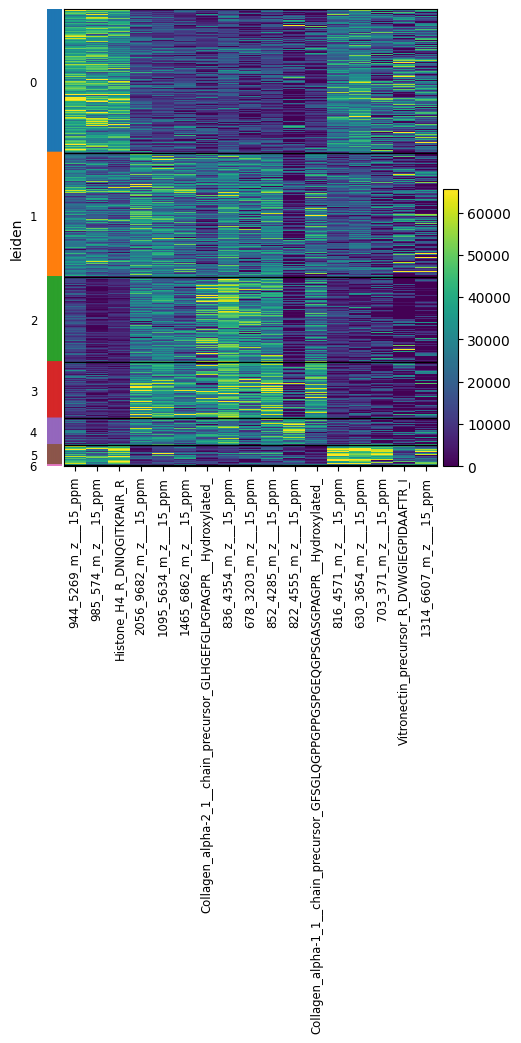

In [14]:
# Heatmap of top markers
n_top_markers = 3
top_markers = []
for cluster in sorted(adata_selected.obs['leiden'].unique().astype(int)):
    cluster_markers = markers[markers['group'] == str(cluster)].head(n_top_markers)
    top_markers.extend(cluster_markers['names'].tolist())

# Remove duplicates while preserving order
top_markers = list(dict.fromkeys(top_markers))

if len(top_markers) > 0:
    sc.pl.heatmap(
        adata_selected, 
        var_names=top_markers[:20],  # Limit to 20 for readability
        groupby='leiden',
        cmap='viridis',
        show_gene_labels=True,
        save=f'_{sample_id}_markers.png'
    )

## Save Results

In [15]:
# Transfer clustering results back to original adata
# (matching indices)
adata.obs['leiden'] = adata_selected.obs['leiden']
adata.obsm['X_pca'] = adata_selected.obsm['X_pca']
adata.obsm['X_umap'] = adata_selected.obsm['X_umap']
adata.uns['pca'] = adata_selected.uns['pca']
adata.uns['neighbors'] = adata_selected.uns['neighbors']
adata.uns['umap'] = adata_selected.uns['umap']
adata.uns['leiden'] = adata_selected.uns['leiden']

# Store clustering parameters
adata.uns['clustering_params'] = {
    'n_pcs': n_pcs,
    'n_neighbors': N_NEIGHBORS,
    'leiden_resolution': LEIDEN_RESOLUTION,
    'umap_min_dist': UMAP_MIN_DIST,
    'random_state': RANDOM_STATE,
    'n_features_used': adata_selected.n_vars,
}

# Save updated AnnData
adata.write_h5ad(sample_file, compression='gzip')
print(f"Updated AnnData saved")

Updated AnnData saved


In [16]:
# Save clustering results as CSV
saved_files = msi_cluster.save_clustering_results(
    adata,
    output_dir=str(OUTPUT_DIR),
    sample_id=sample_id,
    save_umap=True,
    save_clusters=True
)

print(f"Saved files:")
for f in saved_files:
    print(f"  - {f}")

INFO:utils.clustering:Saved clusters to T:\Sammy Data\Third set results\peptides_clustering_results\S001 ovary manual peptides_clusters.csv
INFO:utils.clustering:Saved UMAP to T:\Sammy Data\Third set results\peptides_clustering_results\S001 ovary manual peptides_umap.csv


Saved files:
  - T:\Sammy Data\Third set results\peptides_clustering_results\S001 ovary manual peptides_clusters.csv
  - T:\Sammy Data\Third set results\peptides_clustering_results\S001 ovary manual peptides_umap.csv


In [17]:
# Save marker genes
markers_path = OUTPUT_DIR / f"{sample_id}_markers.csv"
markers.to_csv(markers_path, index=False)
print(f"Markers saved to {markers_path}")

Markers saved to T:\Sammy Data\Third set results\peptides_clustering_results\S001 ovary manual peptides_markers.csv


## Batch Process All Samples

In [18]:
def process_sample_clustering(input_path, output_dir, n_pcs, n_neighbors, 
                              resolution, min_dist, use_spatial, n_top_features,
                              random_state=42):
    """Process a single sample through clustering pipeline."""
    sample_id = input_path.stem
    logger.info(f"Processing {sample_id}...")
    
    # Load
    adata = ad.read_h5ad(input_path)
    
    # Feature selection
    adata_sel = select_features(adata, use_spatial=use_spatial, n_top=n_top_features)
    
    # Adjust n_pcs
    n_pcs_adj = min(n_pcs, adata_sel.n_vars - 1, adata_sel.n_obs - 1)
    
    # PCA
    sc.tl.pca(adata_sel, n_comps=n_pcs_adj, random_state=random_state)
    
    # Neighbors & clustering
    sc.pp.neighbors(adata_sel, n_neighbors=n_neighbors, n_pcs=n_pcs_adj, 
                    random_state=random_state)
    sc.tl.leiden(adata_sel, resolution=resolution, random_state=random_state)
    
    # UMAP
    sc.tl.umap(adata_sel, min_dist=min_dist, random_state=random_state)
    
    # Find markers
    sc.tl.rank_genes_groups(adata_sel, 'leiden', method='wilcoxon')
    markers = sc.get.rank_genes_groups_df(adata_sel, group=None)
    
    # Transfer to original adata
    adata.obs['leiden'] = adata_sel.obs['leiden']
    adata.obsm['X_pca'] = adata_sel.obsm['X_pca']
    adata.obsm['X_umap'] = adata_sel.obsm['X_umap']
    adata.uns['pca'] = adata_sel.uns['pca']
    adata.uns['clustering_params'] = {
        'n_pcs': n_pcs_adj,
        'n_neighbors': n_neighbors,
        'resolution': resolution,
    }
    
    # Save
    adata.write_h5ad(input_path, compression='gzip')
    msi_cluster.save_clustering_results(adata, str(output_dir), sample_id)
    markers.to_csv(output_dir / f"{sample_id}_markers.csv", index=False)
    
    n_clusters = adata.obs['leiden'].nunique()
    
    return {
        'sample_id': sample_id,
        'n_clusters': n_clusters,
        'n_features': adata_sel.n_vars,
        'n_pcs': n_pcs_adj,
        'status': 'success'
    }

In [19]:
# Process all samples
all_results = []

for sample_file in sample_files:
    try:
        result = process_sample_clustering(
            input_path=sample_file,
            output_dir=OUTPUT_DIR,
            n_pcs=N_PCS,
            n_neighbors=N_NEIGHBORS,
            resolution=LEIDEN_RESOLUTION,
            min_dist=UMAP_MIN_DIST,
            use_spatial=USE_SPATIALLY_COHERENT,
            n_top_features=N_TOP_FEATURES,
            random_state=RANDOM_STATE
        )
        all_results.append(result)
    except Exception as e:
        logger.error(f"Error processing {sample_file.stem}: {e}")
        all_results.append({
            'sample_id': sample_file.stem,
            'status': 'error',
            'error': str(e)
        })

# Summary
summary_df = pd.DataFrame(all_results)
summary_df.to_csv(OUTPUT_DIR / "clustering_summary.csv", index=False)
print("\nClustering Summary:")
print(summary_df)

INFO:__main__:Processing S001 ovary manual peptides...


Using 78 spatially coherent channels
computing PCA
    with n_comps=21
    finished (0:00:03)
computing neighbors
    using 'X_pca' with n_pcs = 21
    finished (0:00:30)
running Leiden clustering
    finished (0:08:38)
computing UMAP
    finished (0:03:26)
ranking genes
    finished (0:00:16)


c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\users_\

Using 84 spatially coherent channels
computing PCA
    with n_comps=21
    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 21
    finished (0:00:16)
running Leiden clustering
    finished (0:01:35)
computing UMAP
    finished (0:01:52)
ranking genes
    finished (0:00:09)


c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\users_\

...

Using 80 spatially coherent channels
computing PCA
    with n_comps=21
    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 21
    finished (0:00:12)
running Leiden clustering
    finished (0:01:04)
computing UMAP
    finished (0:01:26)
ranking genes
    finished (0:00:06)


c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\users_\

Using 112 spatially coherent channels
computing PCA
    with n_comps=21
    finished (0:00:03)
computing neighbors
    using 'X_pca' with n_pcs = 21
    finished (0:00:21)
running Leiden clustering
    finished (0:04:02)
computing UMAP
    finished (0:02:25)
ranking genes
    finished (0:00:13)


c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\users_\.conda\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\users_\


Clustering Summary:
                     sample_id  n_clusters  n_features  n_pcs   status
0   S001 ovary manual peptides           7          78     21  success
1   S004 ovary manual peptides           6          84     21  success
2   S005 ovary manual peptides           4          21     20  success
3   S006 ovary manual peptides           5         106     21  success
4   S019 ovary manual peptides           5          89     21  success
5   S020 ovary manual peptides           7         175     21  success
6   S022 ovary manual peptides           8         114     21  success
7   S023 ovary manual peptides          12         183     21  success
8   S024 ovary manual peptides           7         131     21  success
9   S025 ovary manual peptides           8          86     21  success
10  S026 ovary manual peptides           6          79     21  success
11  S030 ovary manual peptides           4          28     21  success
12  S032 ovary manual peptides          14         112  